<a href="https://colab.research.google.com/github/pavanravindrakumar/CodeAlpha_Unemployment_Analysis/blob/main/CodeAlpha_Unemployment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install kagglehub

In [19]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'unemployment-in-india' dataset.
Path to dataset files: /kaggle/input/unemployment-in-india


In [20]:
import pandas as pd
import os

# Check files
files = os.listdir(path)
print(files)

['Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv']


In [21]:
data = pd.read_csv(path + "/Unemployment in India.csv")


In [22]:
data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [24]:
data.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [25]:
data.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [26]:
data.columns = data.columns.str.strip()

print(data.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [27]:
data.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [28]:
data = data.dropna()

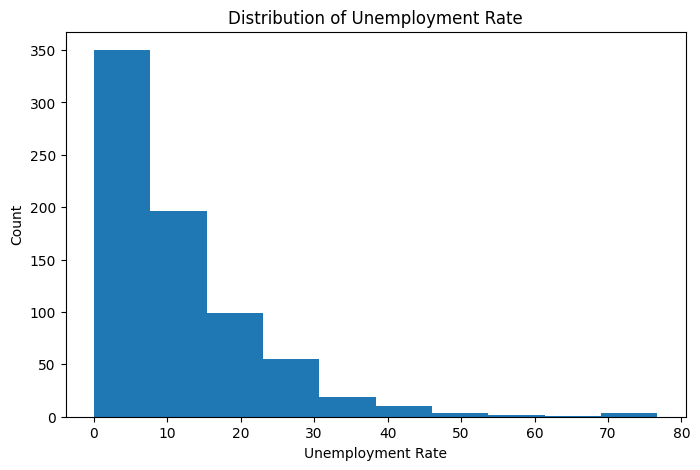

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(data['Estimated Unemployment Rate (%)'])

plt.xlabel("Unemployment Rate")
plt.ylabel("Count")
plt.title("Distribution of Unemployment Rate")

plt.show()

In [30]:
state_avg = data.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

state_avg.sort_values(ascending=False).head(10)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


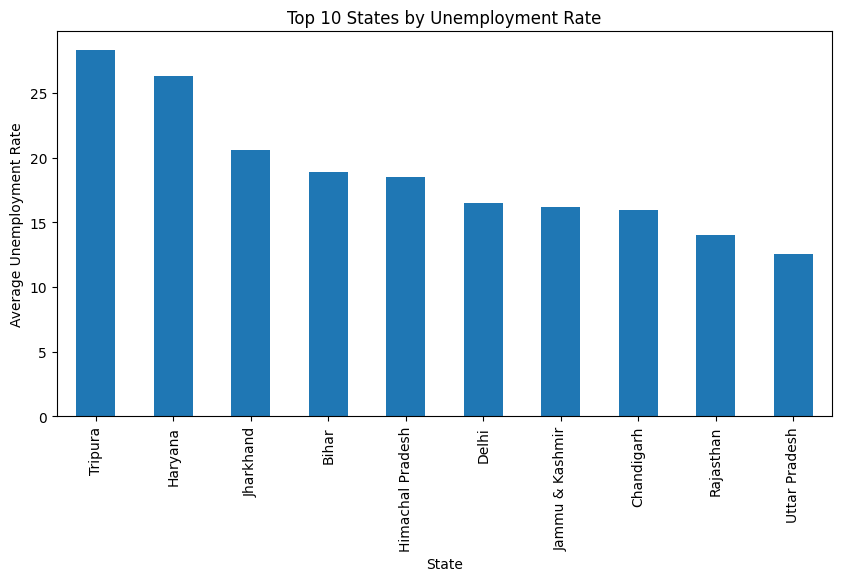

In [31]:
top_states = state_avg.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_states.plot(kind='bar')

plt.title("Top 10 States by Unemployment Rate")
plt.xlabel("State")
plt.ylabel("Average Unemployment Rate")

plt.show()

/tmp/ipykernel_14163/397368778.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Date'] = pd.to_datetime(data['Date'])


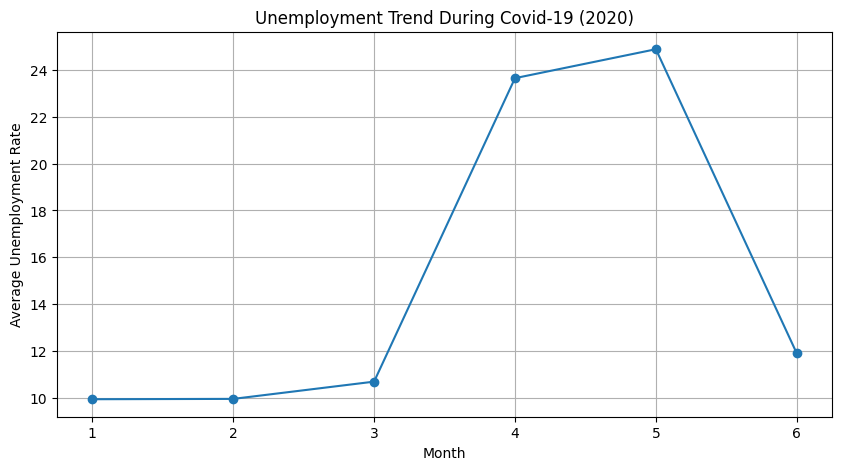

In [32]:
data['Date'] = pd.to_datetime(data['Date'])

covid_data = data[data['Date'].dt.year == 2020]

covid_avg = covid_data.groupby(
    covid_data['Date'].dt.month
)['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))

covid_avg.plot(marker='o')

plt.title("Unemployment Trend During Covid-19 (2020)")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate")

plt.grid()

plt.show()

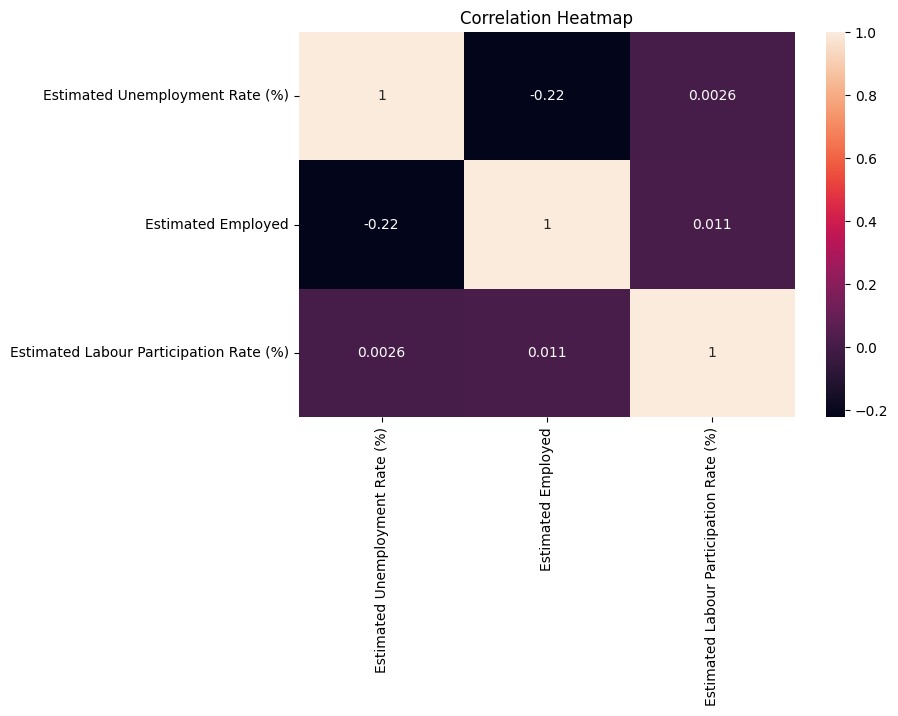

In [33]:
import seaborn as sns

numeric_data = data.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(8,5))

sns.heatmap(numeric_data.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

Insights:
1. Some states showed higher unemployment rates than others.
2. Covid-19 significantly increased unemployment during 2020.
3. Seasonal trends and regional differences were observed.
4. Data visualization helped identify patterns effectively.

Conclusion:
This project analyzed unemployment trends in India using Python.
The analysis showed the impact of Covid-19 and regional differences
in unemployment rates through data visualization techniques.